<a href="https://colab.research.google.com/github/mp-codez/probability-statistics-experiments/blob/solution/transformer_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [11]:
#Load titanic training data from github
titanic_url = "https://github.com/mp-codez/dataset/blob/main/titanic/train.csv?raw=true"
df_titanic_train = pd.read_csv(titanic_url, usecols=['Age', 'Fare', 'Survived'])

In [12]:
df_titanic_train.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [13]:
# Check the missing values
df_titanic_train.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [14]:
df_titanic_train['Age'].fillna(df_titanic_train['Age'].mean(), inplace=True)

/tmp/ipython-input-2297738850.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titanic_train['Age'].fillna(df_titanic_train['Age'].mean(), inplace=True)


In [15]:
# Check the missing values
df_titanic_train.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [16]:
df_titanic_train.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [20]:
X = df_titanic_train.iloc[:,1:3]
y = df_titanic_train.iloc[:,0]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/tmp/ipython-input-3962920907.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


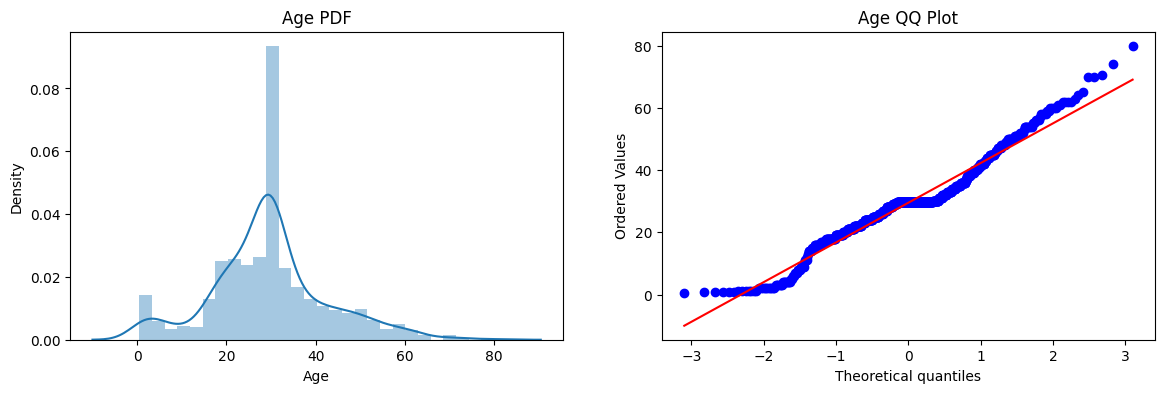

In [28]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')

plt.show()

/tmp/ipython-input-2467747318.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


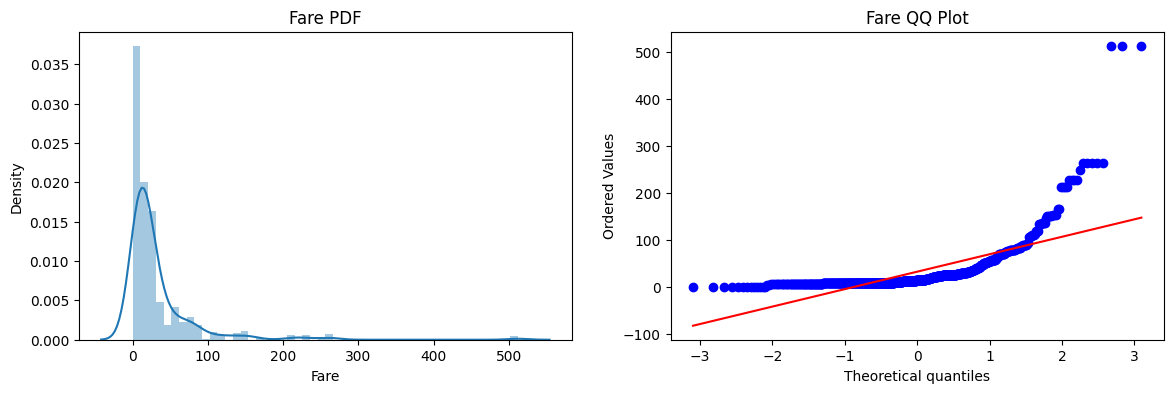

In [29]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [32]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [39]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred2))

Accuracy LR 0.6480446927374302
Accuracy DT 0.659217877094972


In [37]:
# Applying function transformer on both the column age and fare
trf = FunctionTransformer(func=np.log1p)

X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.fit_transform(X_test)

In [38]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)

print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred2))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6759776536312849


In [41]:
# Cross validation
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transformed, y, scoring='accuracy', cv=10)))

LR 0.678027465667915
DT 0.6543820224719101


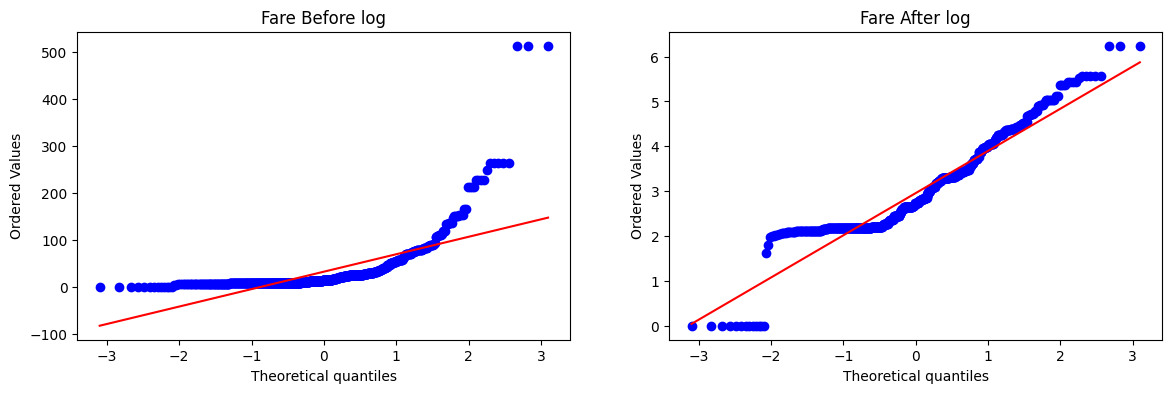

In [42]:
# QQ plot of fare before and after transformation
plt.figure(figsize=(14, 4))
plt.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title("Fare Before log")

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist='norm', plot=plt)
plt.title('Fare After log')

plt.show()

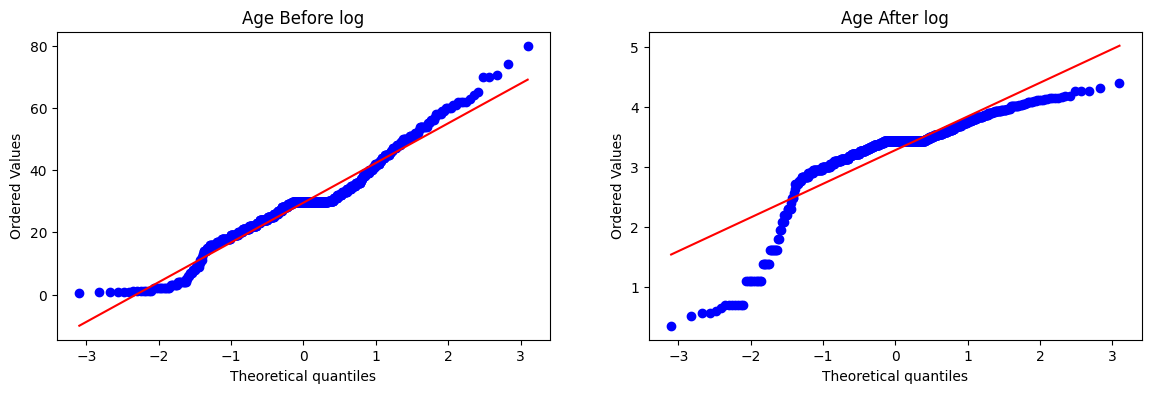

In [43]:
# QQ plot of Age before and after transformation
plt.figure(figsize=(14, 4))
plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title("Age Before log")

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist='norm', plot=plt)
plt.title('Age After log')

plt.show()

In [44]:
# conclusion no need to apply transformation on age column

In [45]:
# Applying transformation only on one column that is fare column
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.fit_transform(X_test)

In [46]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6815642458100558


In [47]:
# Cross validation
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, X_transformed2, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transformed2, y, scoring='accuracy', cv=10)))

LR 0.6712609238451936
DT 0.6543445692883895


In [57]:
def apply_transform(transform):
  X = df_titanic_train.iloc[:,1:3]
  y = df_titanic_train.iloc[:,0]

  trf = ColumnTransformer([('log', FunctionTransformer(transform), ['Fare'])], remainder='passthrough')
  X_trans = trf.fit_transform(X)

  clf = LogisticRegression()

  print("Accuracy", np.mean(cross_val_score(clf, X_trans, y, scoring='accuracy', cv=10)))

  plt.figure(figsize=(14, 4))

  plt.subplot(121)
  stats.probplot(X['Fare'], dist='norm', plot=plt)
  plt.title("Fare Before log")

  plt.subplot(122)
  stats.probplot(X_trans[:,0], dist='norm', plot=plt)
  plt.title('Fare After log')

  plt.show()

In [58]:
"""def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    """

'def apply_transform(transform):\n    X = df.iloc[:,1:3]\n    y = df.iloc[:,0]\n    \n    trf = ColumnTransformer([(\'log\',FunctionTransformer(transform),[\'Fare\'])],remainder=\'passthrough\')\n    \n    X_trans = trf.fit_transform(X)\n    \n    clf = LogisticRegression()\n    \n    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring=\'accuracy\',cv=10)))\n    \n    plt.figure(figsize=(14,4))\n\n    plt.subplot(121)\n    stats.probplot(X[\'Fare\'], dist="norm", plot=plt)\n    plt.title(\'Fare Before Transform\')\n\n    plt.subplot(122)\n    stats.probplot(X_trans[:,0], dist="norm", plot=plt)\n    plt.title(\'Fare After Transform\')\n\n    plt.show()\n    '

Accuracy 0.6622596754057428


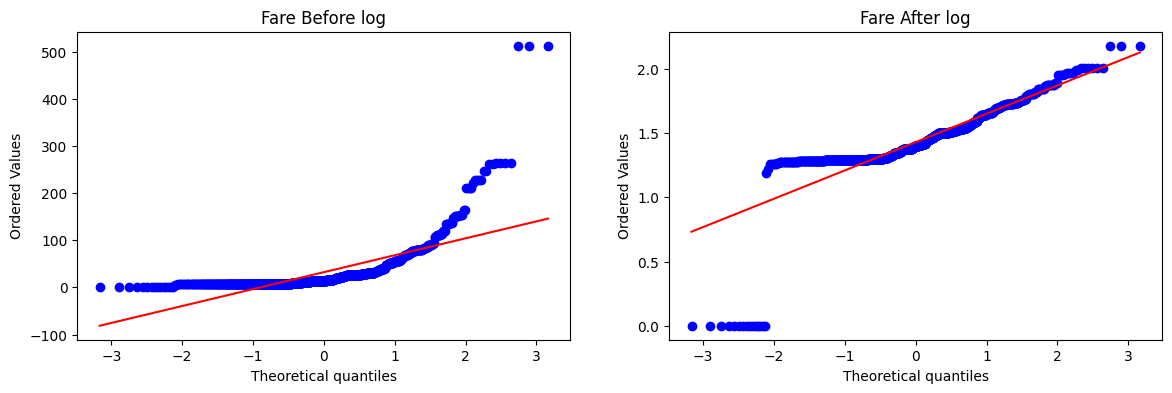

In [68]:
apply_transform(lambda x: x**(1/8))